In [1]:
from functools import partial
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.interpolate import InterpolatedUnivariateSpline

In [2]:
import jax
from jax import config, jit
import jax.numpy as jnp
from jax.lax import fori_loop

In [3]:
from scripts.figures import set_rc_parameters
from scripts.potentials import Potential
from scripts.wave_function import wave_function

In [4]:
# Enable double precision
config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

## Get deuteron wave function for test integral of $\frac{2}{\pi} \int_0^\infty dk\, k^2\, |\psi_d(k)|^2$

In [6]:
# AV18 potential in 3S1-3D1 channel
kvnn, kmax, kmid, ntot = 6, 25.0, 4.0, 120
potential = Potential(kvnn, '3S1', kmax, kmid, ntot)

# Hamiltonian in units MeV
H_matrix = potential.load_hamiltonian()
psi_unitless = wave_function(H_matrix)  # Weights attached
psi_0_unitless = psi_unitless[:ntot]
psi_2_unitless = psi_unitless[ntot:]
k_array, k_weights = potential.load_mesh()
psi_0_units = psi_0_unitless / jnp.sqrt(k_weights)  # Divide out weights
psi_2_units = psi_2_unitless / jnp.sqrt(k_weights)
psi_squared_units = psi_0_units ** 2 + psi_2_units ** 2

# # Interpolate integrand 2 / \pi * k^2 * \psi(k)
# integrand = InterpolatedUnivariateSpline(k_array, psi_squared_units)

In [7]:
k_jax = jnp.asarray(k_array)
psi_squared_jax = jnp.asarray(psi_squared_units)

@jit
def integrand(k):
    """JAX function for integrand as a function of k."""
    
    return jnp.interp(k, k_jax, psi_squared_jax)

In [8]:
# First check that integrand over the same mesh gives correct normalization
norm = jnp.sum(integrand(k_array) * k_weights)
print(f"Normalization with Gaussian quadrature = {norm}")

Normalization with Gaussian quadrature = 1.0000000000000004


## MC integration

In [9]:
class UniformSampling:
    
    def __init__(self, integrand, num_samples, sig=1.0):
        
        # Set integrand as instance attribute
        self.integrand = integrand
        self.num_samples = num_samples
        self.sig = sig
        
        self.acc_s = jnp.zeros(num_samples)
        self.x_s = jnp.zeros(num_samples)
        
    @partial(jit, static_argnums=(0,))
    def integrate_uniform_sampling(self, a, b):

        # Get samples over [a, b]
        key = jax.random.PRNGKey(0)
        self.acc_s, self.x_s = self.metropolis_walk_uniform(key, a, b)
        
        # Integrate over the interval [a, b]
        vol = b - a
        integral = vol * jnp.mean(integrand(self.x_s))
        
        return self.acc_s, self.x_s, integral

    @partial(jit, static_argnums=(0,))
    def metropolis_walk_uniform(self, key, a, b):

        key, _ = jax.random.split(key)
        
        # Initial point
        x_o = a + (b - a) * jax.random.uniform(key)
        
        # Loop over number of samples
        x_o, key, self.acc_s, self.x_s = fori_loop(
            0, self.num_samples, self.step_uniform,
            (x_o, key, self.acc_s, self.x_s)
        )
        
        return self.acc_s, self.x_s
        
    @partial(jit, static_argnums=(0,))
    def step_uniform(self, i, loop_carry):
            
        x_o, key, self.acc_s, self.x_s = loop_carry             
        f_o = self.integrand(x_o)
        key, subkey = jax.random.split(key)
        x_n = x_o + self.sig * jax.random.normal(subkey)
        f_n = self.integrand(x_n)

        key, subkey = jax.random.split(key)
        
        # This will accept all samples in [a, b]
        acceptance_ratio = (self.uniform_distribution(x_n, a, b)
                            / self.uniform_distribution(x_o, a, b))
        accept = jnp.minimum(1.0, acceptance_ratio)
        x_o = jnp.where(jax.random.uniform(subkey) < accept, x_n, x_o)
        
        self.acc_s = self.acc_s.at[i].set(accept.astype('float32'))
        self.x_s = self.x_s.at[i].set(x_o)
            
        return x_o, key, self.acc_s, self.x_s
    
    @partial(jit, static_argnums=(0,))
    def uniform_distribution(self, x, a, b):
        """Uniform distribution over [a, b]."""
        
        # Check if a <= x <= b
        cond = jnp.logical_and(x >= a, x <= b)
        
        return jnp.where(cond, 1 / (b - a), 0)

In [10]:
# Work in progress
class GaussianSampling:
    
    def __init__(self, integrand, num_samples, sig=1.0):
        
        # Set integrand as instance attribute
        # self.integrand = integrand
        self.integrand = lambda x, a, b: integrand(x) / self.weight(x, a, b)
        self.num_samples = num_samples
        self.sig = sig
        self.acc_s = jnp.zeros(num_samples)
        self.x_s = jnp.zeros(num_samples)

    @partial(jit, static_argnums=(0,))
    def integrate_metropolis(self, a, b):

        # Get samples over [a, b]
        key = jax.random.PRNGKey(0)
        self.acc_s, self.x_s = self.sample_gaussian(key, a, b)
        
#         integral = jnp.mean(self.integrand(self.x_s)
#                             / self.weight(self.x_s, a, b))
        integral = (jnp.mean(self.integrand(self.x_s, a, b)
                             / self.weight(self.x_s, a, b)))
        
        return self.acc_s, self.x_s, integral

    @partial(jit, static_argnums=(0,))
    def sample_gaussian(self, key, a, b):

        key, _ = jax.random.split(key)
        
        # Initial point
        x_o = a + (b - a) * jax.random.uniform(key)
        
        # Loop over number of samples
        x_o, key, self.acc_s, self.x_s = fori_loop(
            0, self.num_samples, self.step, (x_o, key, self.acc_s, self.x_s)
        )
        
        return self.acc_s, self.x_s
        
    @partial(jit, static_argnums=(0,))
    def step(self, i, loop_carry):
            
        x_o, key, self.acc_s, self.x_s = loop_carry             
        key, subkey = jax.random.split(key)
        x_n = x_o + self.sig * jax.random.normal(subkey)

        key, subkey = jax.random.split(key)
        
        # This will accept based on ratio of \psi_d(x_n)^2 / \psi_d(x_o)^2
        acceptance_ratio = self.weight(x_n, a, b) / self.weight(x_o, a, b)
        acceptance_probability = jnp.minimum(1.0, acceptance_ratio)
        u = jax.random.uniform(subkey)
        accept = u < acceptance_probability
        x_o = jnp.where(accept, x_n, x_o)
        
        self.acc_s = self.acc_s.at[i].set(accept.astype('float32'))
        self.x_s = self.x_s.at[i].set(x_o)
            
        return x_o, key, self.acc_s, self.x_s
    
    @partial(jit, static_argnums=(0,))
    def weight(self, x, a, b):
        """Weight by Gaussian function excluding points outside of [a, b]."""

        sigma = 1.0
        gaussian = (jnp.exp(-x**2 / (2 * sigma ** 2))
                    / jnp.sqrt(2 * jnp.pi * sigma ** 2))
        
        # Check if a <= x <= b
        cond = jnp.logical_and(x >= a, x <= b)
        
        return 2 * jnp.where(cond, gaussian, 0)

### Test for uniform sampling first

Normalization by uniform sampling = 1.01420


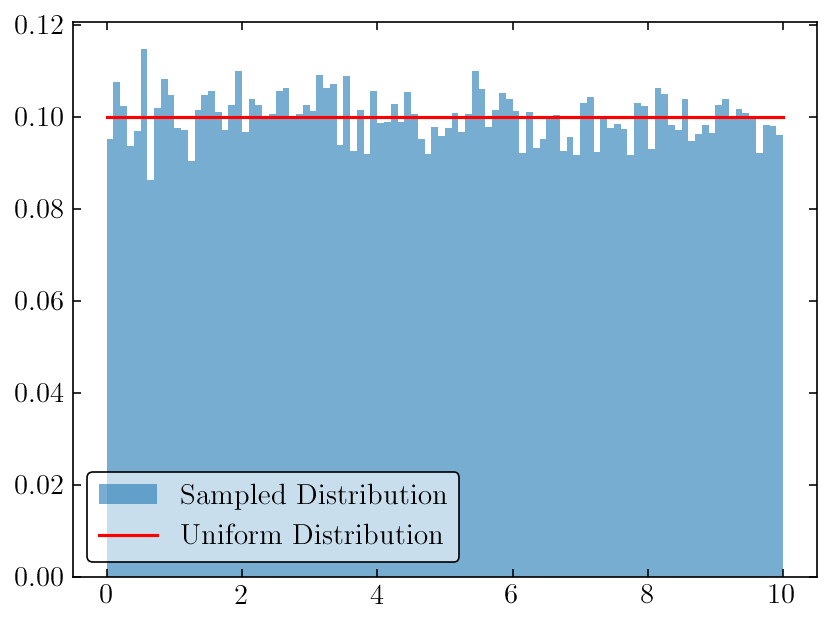

In [11]:
key = jax.random.PRNGKey(0)
a, b = 0, 10.0  # Interval boundaries
sig = (b - a) / 2
num_samples = 100000


mc = UniformSampling(integrand, num_samples, sig=sig)

acc_s, x_s, integral = mc.integrate_uniform_sampling(a, b)

print(f"Normalization by uniform sampling = {integral:.5f}")

# Plotting
plt.hist(x_s, bins=100, density=True, alpha=0.6, label="Sampled Distribution")
x = jnp.linspace(a, b, 1000)
plt.plot(x, mc.uniform_distribution(x, a, b), label="Uniform Distribution",
         color='red')
plt.legend()
plt.show()

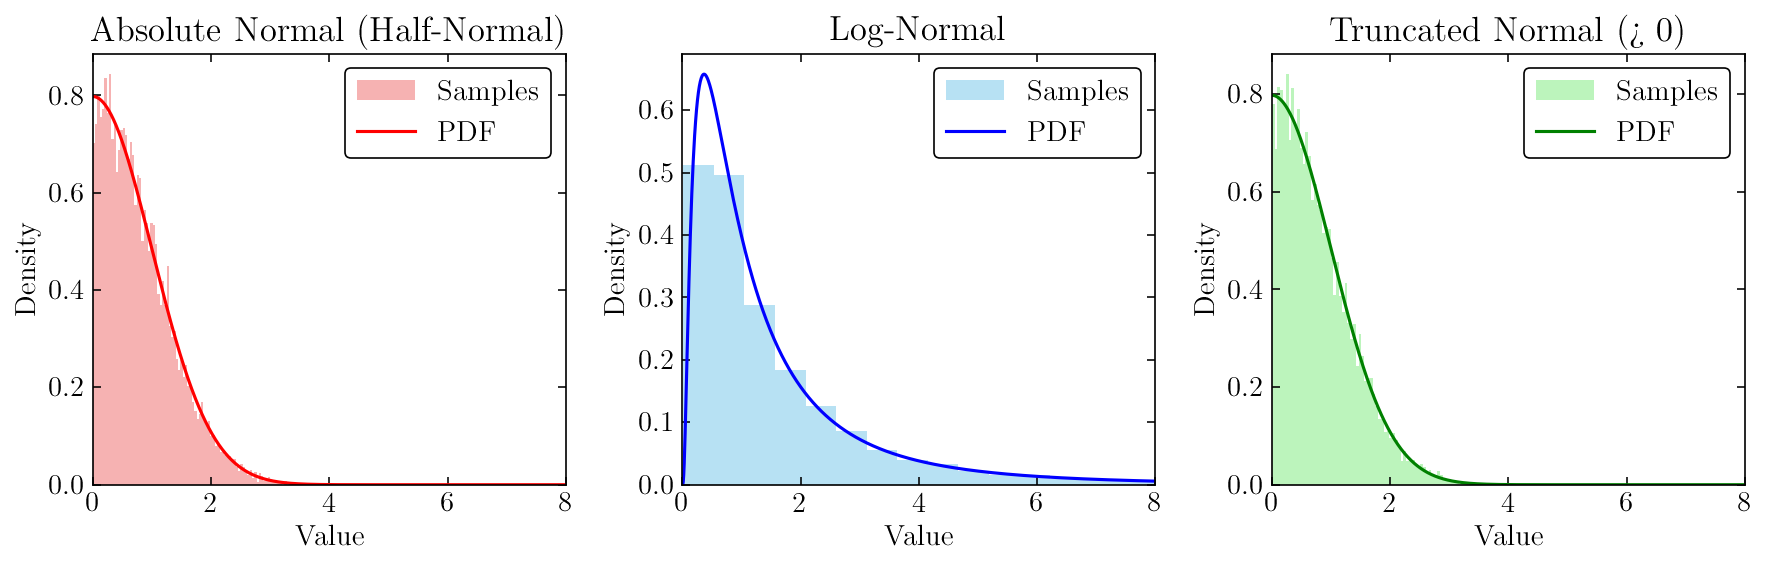

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import halfnorm, lognorm, truncnorm

# Set random seed
rng = np.random.default_rng(seed=0)

# Parameters
mu, sigma = 0.0, 1.0
num_samples = 10000

# Sample distributions
abs_normal_samples = np.abs(rng.normal(loc=mu, scale=sigma, size=num_samples))
log_normal_samples = np.exp(mu + sigma * rng.normal(size=num_samples))

def truncated_normal_positive(size, mu=0.0, sigma=1.0):
    samples = []
    while len(samples) < size:
        x = rng.normal(loc=mu, scale=sigma, size=size)
        samples.extend(x[x > 0])
    return np.array(samples[:size])

trunc_normal_samples = truncated_normal_positive(num_samples)

# X values for PDFs
x = np.linspace(0, 8, 1000)

# Theoretical PDFs
half_normal_pdf = halfnorm(scale=sigma).pdf(x)
log_normal_pdf = lognorm(s=sigma, scale=np.exp(mu)).pdf(x)
trunc_normal_pdf = truncnorm(a=(0 - mu) / sigma, b=np.inf, loc=mu, scale=sigma).pdf(x)

# Plotting
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(abs_normal_samples, bins=100, density=True, alpha=0.6, color='lightcoral', label='Samples')
plt.plot(x, half_normal_pdf, 'r', label='PDF')
plt.title('Absolute Normal (Half-Normal)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 8)
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(log_normal_samples, bins=100, density=True, alpha=0.6, color='skyblue', label='Samples')
plt.plot(x, log_normal_pdf, 'b', label='PDF')
plt.title('Log-Normal')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 8)
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(trunc_normal_samples, bins=100, density=True, alpha=0.6, color='lightgreen', label='Samples')
plt.plot(x, trunc_normal_pdf, 'g', label='PDF')
plt.title('Truncated Normal (> 0)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.xlim(0, 8)
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
import jax
nsamples, ndim = 100, 3
key = jax.random.PRNGKey(0)
samples = jax.random.uniform(key, shape=(nsamples,ndim))
print(samples)

[[0.52713866 0.07686939 0.22010313]
 [0.61904823 0.03063406 0.14881671]
 [0.07305035 0.04099614 0.96125402]
 [0.64643875 0.87214541 0.50414964]
 [0.60755848 0.13117166 0.03728732]
 [0.06365893 0.78258792 0.86378077]
 [0.05289944 0.58596949 0.61651036]
 [0.51984369 0.22094794 0.38427092]
 [0.95828131 0.28601951 0.84046561]
 [0.06532192 0.77446376 0.59186064]
 [0.16603758 0.57724196 0.11929713]
 [0.7254353  0.03806135 0.44757432]
 [0.94395016 0.56234813 0.83530379]
 [0.54000437 0.8406455  0.8016482 ]
 [0.02070049 0.12034663 0.7602501 ]
 [0.65595685 0.46658984 0.76382976]
 [0.81824726 0.89794318 0.42470156]
 [0.34426959 0.05647766 0.1919629 ]
 [0.84761416 0.20438363 0.51127149]
 [0.17259734 0.52099614 0.35163327]
 [0.97297473 0.32434205 0.21005994]
 [0.59599976 0.5233838  0.96766202]
 [0.86134652 0.73355689 0.81182691]
 [0.22684826 0.05489769 0.23685512]
 [0.42309798 0.89626    0.65205179]
 [0.50775107 0.03984725 0.73720003]
 [0.74386325 0.28805621 0.95636011]
 [0.39253235 0.57450393 0.49